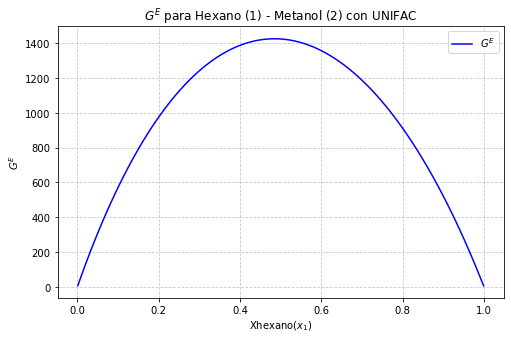

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def GE(x1_array, T=283.15):

    # Grupos: 0 = CH3, 1 = CH2, 2 = OH
    # Molecula 1 (Hexano): 2x CH3, 4x CH2, 0x OH
    # Molecula 2 (Metanol): 1x CH3, 0x CH2, 1x OH
    nu = np.array([
        [2, 4, 0],  
        [1, 0, 1]   
    ])
    
    R_k = np.array([0.9011, 0.6744, 1.0000])
    Q_k = np.array([0.848, 0.540, 1.200])
    
    a_mn = np.array([
        [0.0, 0.0, 644.6],    
        [0.0, 0.0, 644.6],    
        [328.2, 328.2, 0.0]   
    ])
    

    Psi = np.exp(-a_mn / T)
    z = 10.0
    

    r = np.sum(nu * R_k, axis=1)
    q = np.sum(nu * Q_k, axis=1)
    l = (z / 2) * (r - q) - (r - 1)
    
    GE_RT_list = []
    

    for x1 in x1_array:
        x = np.array([x1, 1 - x1])
        
        # Combinatorial
        Phi = (x * r) / np.sum(x * r)
        Theta = (x * q) / np.sum(x * q)
        
        ln_gamma_C = np.log(Phi / x) + (z / 2) * q * np.log(Theta / Phi) + l - (Phi / x) * np.sum(x * l)
        
        # Residual
        sum_nu_x = np.sum(x[:, np.newaxis] * nu, axis=0) 
        X_m = sum_nu_x / np.sum(sum_nu_x)
        Theta_m = X_m * Q_k / np.sum(X_m * Q_k)
        
        # ln Gamma_k
        ln_Gamma_k = np.zeros(3)
        for k in range(3):
            term1 = np.sum(Theta_m * Psi[:, k])
            term2 = sum((Theta_m[m] * Psi[k, m]) / np.sum(Theta_m * Psi[:, m]) for m in range(3))
            ln_Gamma_k[k] = Q_k[k] * (1 - np.log(term1) - term2)
            
        #ln Gamma_k_i
        ln_Gamma_k_i = np.zeros((2, 3))
        for i in range(2):
            X_m_i = nu[i] / np.sum(nu[i])
            Theta_m_i = X_m_i * Q_k / np.sum(X_m_i * Q_k)
            for k in range(3):
                if nu[i, k] > 0:
                    term1 = np.sum(Theta_m_i * Psi[:, k])
                    term2 = sum((Theta_m_i[m] * Psi[k, m]) / np.sum(Theta_m_i * Psi[:, m]) for m in range(3) if Theta_m_i[m] > 0)
                    ln_Gamma_k_i[i, k] = Q_k[k] * (1 - np.log(term1) - term2)
                    
        # 4. ln_Gamma_R
        ln_gamma_R = np.zeros(2)
        for i in range(2):
            ln_gamma_R[i] = np.sum(nu[i] * (ln_Gamma_k - ln_Gamma_k_i[i]))
            
        # GE
        ln_gamma = ln_gamma_C + ln_gamma_R
        GE_RT = x[0] * ln_gamma[0] + x[1] * ln_gamma[1]
        
        GE_RT_list.append(GE_RT)
        
    return np.array(GE_RT_list)

x_vals = np.linspace(0.001, 0.999, 100) 
y_vals = (GE(x_vals))*(R*T)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, label='$G^E$', color='blue')
plt.title('$G^E$ para Hexano (1) - Metanol (2) con UNIFAC')
plt.xlabel('Xhexano($x_1$)')
plt.ylabel('$G^E$')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()